In [4]:
import rasterio
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def load_sar_tiff_tf(path):
    def _read(p):
        path_str = p.item()

        with rasterio.open(path_str) as src:
            vv = src.read(1).astype(np.float32)
            vh = src.read(2).astype(np.float32)

        # Fixed-range normalization (dB)
        vv = np.clip(vv, -35.0, 5.0)
        vh = np.clip(vh, -40.0, 0.0)

        vv = (vv + 35.0) / 40.0
        vh = (vh + 40.0) / 40.0

        img = np.stack([vv, vh], axis=-1)

        # Resize 2048 → 512
        img = tf.image.resize(img, (512, 512), method="bilinear").numpy()

        return img.astype(np.float32)

    img = tf.numpy_function(_read, [path], tf.float32)
    img.set_shape([512, 512, 2])
    return img

In [6]:
oil_img = load_sar_tiff_tf('/Volumes/Windows8_OS/Dataset/Dataset-OG/Train/Images/Oil/00000.tif')

I0000 00:00:1768563771.889949 3391041 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1768563771.890752 3391041 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


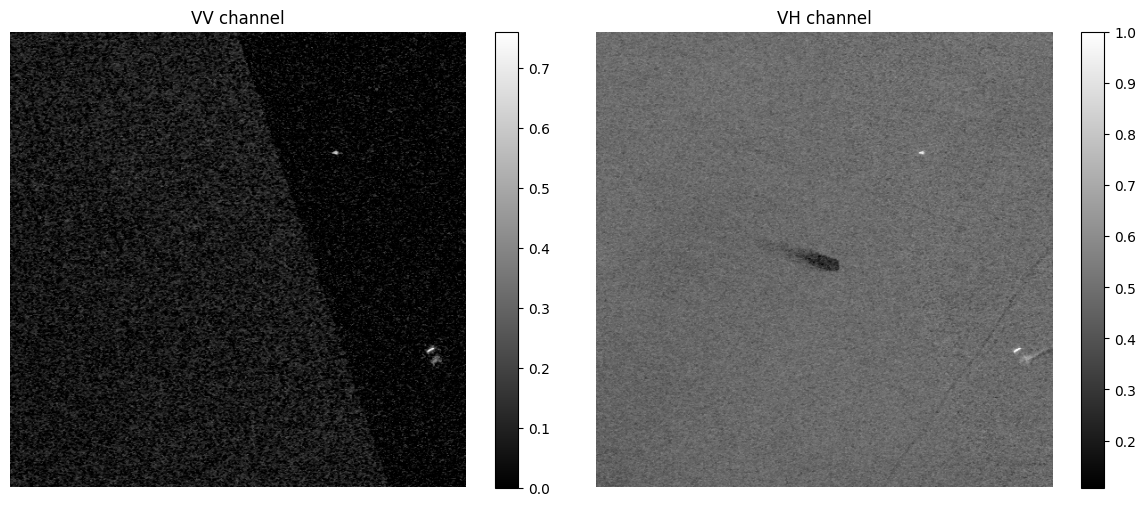

In [7]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("VV channel")
plt.imshow(oil_img[..., 0], cmap="gray")
plt.colorbar()
plt.axis("off")

plt.subplot(1,2,2)
plt.title("VH channel")
plt.imshow(oil_img[..., 1], cmap="gray")
plt.colorbar()
plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
combined = 0.3 * oil_img[..., 0] + 0.7 * oil_img[..., 1]

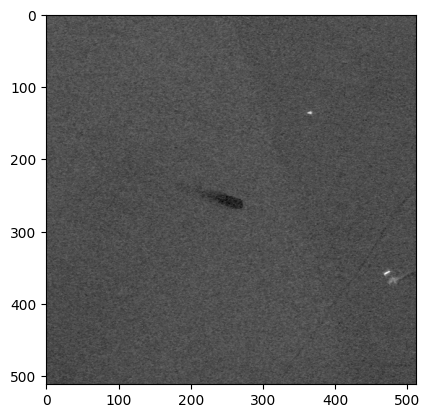

In [9]:
plt.imshow(combined, cmap="gray")